# BMA MCMC
- After having implemented the MCMC, I feel the model selection is still a point of unresolved uncertainty.
- Examining the NLLs, the models have can have similar NLL values but we choose just one model.
- Rather than using a full RJMCMC, we can approximate the model selection by MCMC sampling the top few models and then creating a multi-model sample-set by proportionally sampling from the model samples according to their likelihood.
- We can use softmax to assign the probabilities.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize

import celerite2
from celerite2 import terms

from prettytable import PrettyTable

import sys
from pathlib import Path

sys.path.append(str(Path('../..').resolve()))

from helpers.df_ops import prepare_df, split_df, clean_df
from helpers.priors import find_classify_signals, get_priors

def set_params(log_params, k, gp):
    # k = len(log_params) // 3
    params = np.exp(log_params)
    sigmas = params[0:k]
    rhos = params[k:2*k]
    qs = params[2*k::]
    
    gp.kernel = terms.SHOTerm(sigma=sigmas[0], rho=rhos[0], Q=qs[0])
    for k_idx in range(1,k):
        gp.kernel += terms.SHOTerm(sigma=sigmas[k_idx], rho=rhos[k_idx], Q=qs[k_idx])
    return gp

def NLL(log_params, gp, k, y):
    gp = set_params(log_params, k, gp)
    gp.recompute(quiet=True)
    return -gp.log_likelihood(y)

def lnPost(log_params, gp, k, y, initial_guesses, bounds, prior_std=3):
    if np.any(log_params < bounds[:, 0]) or np.any(log_params > bounds[:, 1]):
        return -np.inf
    gp = set_params(log_params, k, gp)
    gp.recompute(quiet=True)
    ll = gp.log_likelihood(y)
    if not np.isfinite(ll):
        return -np.inf
    return ll - 0.5 * np.sum(((np.exp(log_params) - np.exp(initial_guesses)) / prior_std) ** 2)


In [2]:
datapath = r"../../Data/benchmark/HD201091_Mt_wilson_data.txt"

direct_bound_tol = 0.1
sm2016_bound_tol = 0.2
mean_bound_tol = 1

add_prefix = False
relative = True
train_split = 0.8
valid_split = 0.19

star_type = "G"
star_name = "HD201091"

error_percent = 2.5
sigma_upper_mult = 5.0
q_bounds_in = [5, 100]

verbose = True
plot = True
loop_verbose = True
loop_plot = False
loop_savefigs = False
results_verbose = True
results_plot = True
ax = None
result_plot_cadence = 50
result_plot_extra = 1000

require_mid = True

n_walkers = 32

SEED = 1701

Removed 0 datapoints which had NaN.
Removed 19 datapoints that were deemed ourliers by tolerance in sind of 4 times MAD.


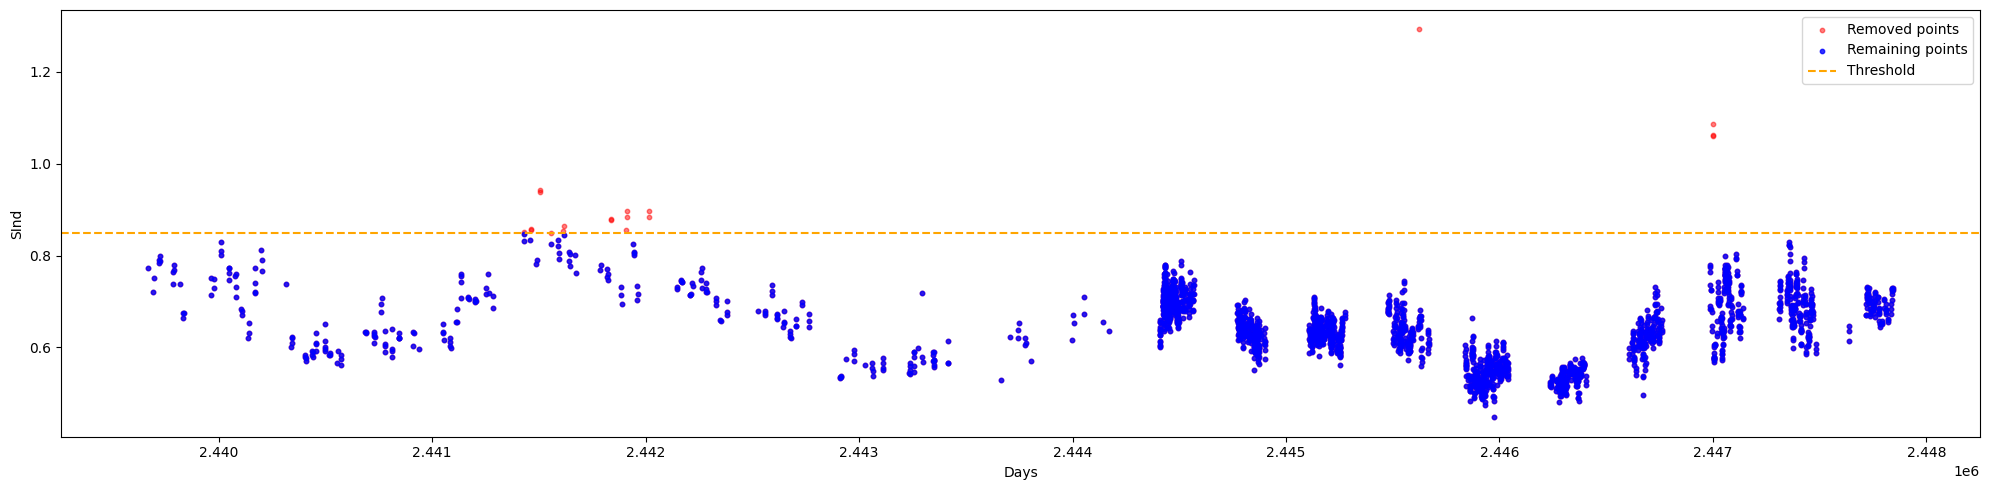

In iteration 0, period at 2730.68 days was accepted.
In iteration 1, period at 12043.36 days was accepted.
Peak at period 1366.67 days was identified to be an alias of 2730.68 days at mult 0.50 by tolerance 0.00.
In iteration 2, period at 505.26 days was accepted.
Peak at period 1377.25 days was identified to be an alias of 2730.68 days at mult 0.50 by tolerance 0.01.
In iteration 3, period at 290.64 days was accepted.
In iteration 4, period at 36.97 days was accepted.
Peak at period 2070.03 days was identified to be an alias of 505.26 days at mult 4.00 by tolerance 0.02.
In iteration 5, period at 443.94 days was accepted.
Peak at period 36.60 days was identified to be an alias of 36.97 days at mult 1.00 by tolerance 0.01.
In iteration 6, period at 39.89 days was accepted.
In iteration 7, period at 33.32 days was accepted.
Peak at period 156.32 days was identified to be an alias of 39.89 days at mult 4.00 by tolerance 0.02.
Peak at period 252.68 days was identified to be an alias of 50

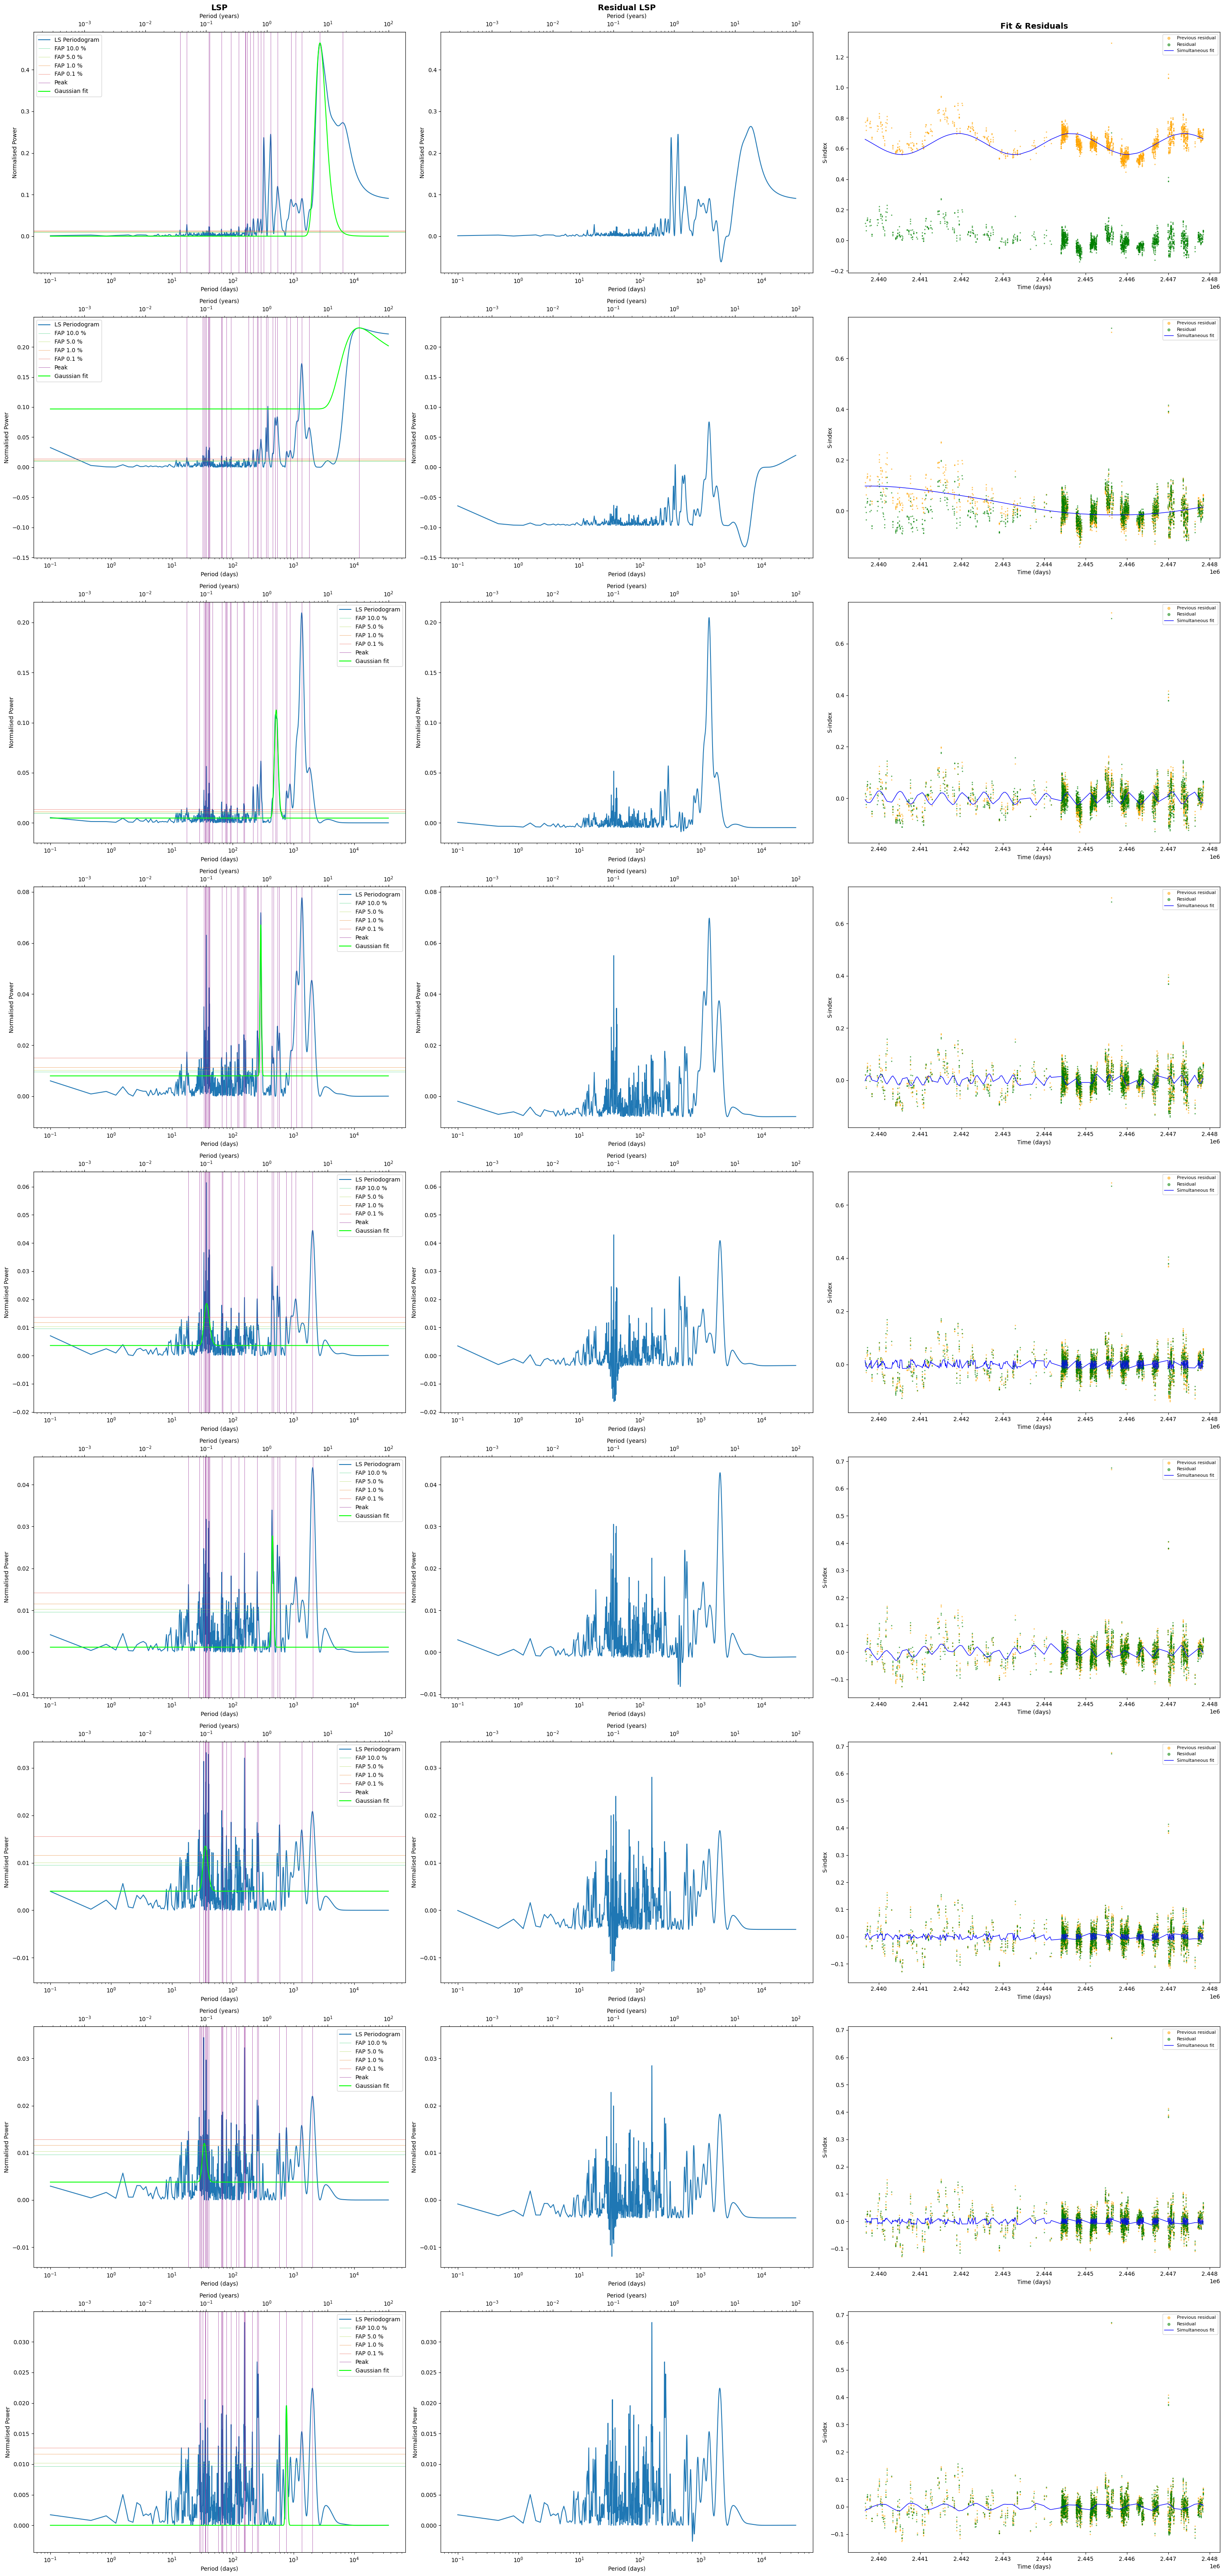

Accepted periods and their heights
+----------+-------+--------+--------------+
|   Days   | Years | Height |     SNR      |
+----------+-------+--------+--------------+
| 2730.68  |  7.48 | 0.4644 |   23570.79   |
| 12043.36 | 33.00 | 0.2316 | 117241745.13 |
|  505.26  |  1.38 | 0.1082 |    18.65     |
|  290.64  |  0.80 | 0.0718 |    10.01     |
|  36.97   |  0.10 | 0.0614 |     9.87     |
|  443.94  |  1.22 | 0.0339 |     7.53     |
|  39.89   |  0.11 | 0.0329 |     6.19     |
|  33.32   |  0.09 | 0.0345 |     7.37     |
|  762.59  |  2.09 | 0.0196 |    13.95     |
+----------+-------+--------+--------------+


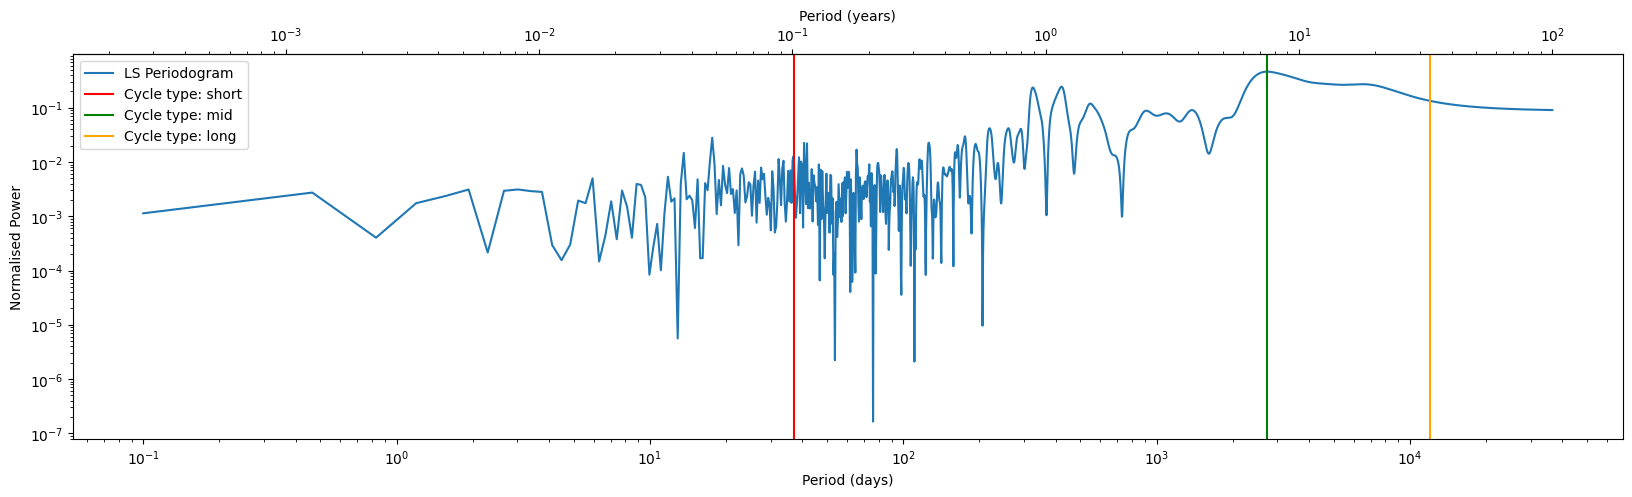

Classified Signals
+------------+------------+-------------+
| Cycle Type | Prior Days | Prior Years |
+------------+------------+-------------+
|   Short    |   36.97    |     0.10    |
|    Mid     |  2730.68   |     7.48    |
|    Long    |  12043.36  |    33.00    |
+------------+------------+-------------+
+------------+------------+-------------+----------------------+----------------+--------+
| Cycle Type | Prior Days | Prior Years |     Bounds Days      |  Bounds Years  | Source |
+------------+------------+-------------+----------------------+----------------+--------+
|   Short    |   36.97    |     0.10    |    (33.27, 40.66)    |  (0.09, 0.11)  | found  |
|    Mid     |  2730.68   |     7.48    |  (2457.62, 3003.75)  |  (6.73, 8.23)  | found  |
|    Long    |  12043.36  |    33.00    | (10839.03, 13247.70) | (29.70, 36.30) | found  |
+------------+------------+-------------+----------------------+----------------+--------+


In [3]:
# Read the data into a "raw" df
raw_df = pd.read_csv(datapath, sep=r'\s+', skip_blank_lines=True)

# Prep the df adds the column names etc
data_df = prepare_df(raw_df, add_prefix=add_prefix, relative=relative)

# Split the data
dirty_train_df, dirty_valid_df, test_df = split_df(data_df,
                                                train_split=train_split, valid_split=valid_split)

# Clean the dataset for outliers
train_df, valid_df, _ = clean_df(dirty_train_df, dirty_valid_df, tol=4,
                        verbose=verbose, plot=plot)

# Classify signal data and get priors
classified_signal_data = find_classify_signals(dirty_train_df,
                                        plot_fitpeaks=plot, verbose_fitpeaks=verbose,
                                        plot_genpriors=plot, verbose_genpriors=verbose)

rho_priors, rho_prior_bounds, rho_sources = get_priors(classified_signal_data,
                                                                star_type=star_type,
                                                                direct_bound_tol = direct_bound_tol, 
                                                                sm2016_bound_tol = sm2016_bound_tol, 
                                                                mean_bound_tol = mean_bound_tol,
                                                                verbose=verbose)


In [5]:
#-----Do the model training and comparison---------
train_yerr = train_df['sind'] * error_percent / 100

train_mean = train_df['sind'].mean()
train_std  = train_df['sind'].std()

# Define the prior combos to try (k, [[q_priors], [rho_priors]])
prior_combos = {
        "1s":    {'k': 1, 'q_priors': None,          'cycle_keys': ['short']},
        "1m":    {'k': 1, 'q_priors': None,          'cycle_keys': ['mid']},
        "1l":    {'k': 1, 'q_priors': None,          'cycle_keys': ['long']},

        "2sm":   {'k': 2, 'q_priors': None,          'cycle_keys': ['short', 'mid']},
        "2ml":   {'k': 2, 'q_priors': None,          'cycle_keys': ['mid',   'long']},
        "2sl":   {'k': 2, 'q_priors': None,          'cycle_keys': ['short', 'long']},

        "3sml":  {'k': 3, 'q_priors': None,          'cycle_keys': ['short', 'mid', 'long']},

        "const": {'k': 1, 'q_priors': "overdamped",  'cycle_keys': ['mid']},
}

if require_mid:
        prior_combos = {key: val for key, val in prior_combos.items() if 'mid' in val['cycle_keys']}

#-----Set up the loop----------
# We wish to store the NLPD, gp, params, inital_guess, and bounds for all combos 
combo_results = {} # Dict key = combo name

#----Run the loop----------
for combo_name, combo_info in prior_combos.items():

        k = combo_info['k']
        q_prior_type = combo_info['q_priors']
        cycle_keys = combo_info['cycle_keys']

        np.random.seed(SEED)

        # Set up q priors
        if q_prior_type == 'overdamped':
                q_0s     = [np.random.uniform(0, 0.5) for _ in range(k)]
        else:
                q_0s     = [np.random.uniform(0.5, 1) for _ in range(k)]

        # Set up remaining priors
        sigma_0s = [train_std / k for _ in range(k)]
        rho_0s = [rho_priors[cycle_key] for cycle_key in cycle_keys]

        # Form initial guess
        initial_guess = np.concatenate([
                np.log(sigma_0s),
                np.log(rho_0s),
                np.log(q_0s)
        ])

        # Set up optimisation bounds
        if q_prior_type == 'overdamped':
                q_bounds     = [(-np.inf, np.log(0.5)) for _ in range(k)]
        else:
                q_bounds     = [(np.log(q_bounds_in[0]), np.log(q_bounds_in[1])) for _ in range(k)]

        sigma_upper  = train_std * sigma_upper_mult
        sigma_bounds = [(np.log(1e-4), np.log(sigma_upper)) for _ in range(k)]
        rho_bounds   = np.log([rho_prior_bounds[cycle_key] for cycle_key in cycle_keys])

        bounds = np.concatenate([sigma_bounds, rho_bounds, q_bounds])

        # Create the initial kernel for this iteration
        kernel = terms.SHOTerm(sigma=sigma_0s[0], rho=rho_0s[0], Q=q_0s[0])
        for k_idx in range(1, k):
                kernel += terms.SHOTerm(sigma=sigma_0s[k_idx], rho=rho_0s[k_idx], Q=q_0s[k_idx])

        # Define and compute the GP
        gp = celerite2.GaussianProcess(kernel, mean=train_mean)
        gp.compute(train_df['day'], yerr=train_yerr)

        # Train the GP
        gp_results = minimize(
                NLL, initial_guess,
                args=(gp, k, train_df['sind'].to_numpy()),
                method='L-BFGS-B',
                bounds=bounds
                )

        gp   = set_params(gp_results.x, k, gp)
        gp.recompute()
        best_params = np.exp(gp_results.x)

        # Predict on validation set
        mu, cov = gp.predict(train_df['sind'], t=valid_df['day'], return_var=True)
        std = np.sqrt(cov)

        # Model comparison via NLPD
        y_valid    = valid_df['sind'].to_numpy()
        valid_yerr = valid_df['sind'] * error_percent / 100
        total_var  = cov + valid_yerr**2
        nlpd_per_point = 0.5 * np.log(2 * np.pi * total_var) + (y_valid - mu)**2 / (2 * total_var)
        mean_nlpd = nlpd_per_point.mean()

        # Store model things
        combo_results[combo_name] = {
                "NLPD" : mean_nlpd,
                "gp" : gp,
                "params" : best_params,
                "initial_guess" : initial_guess,
                "bounds": bounds,
        }

        # If desired, plot the predictions this model makes
        if loop_plot:
                loop_fig, loop_ax = plt.subplots(figsize=(20, 5))
                loop_ax.scatter(train_df['year'], train_df['sind'], color='blue', label='Training', marker='x')
                loop_ax.plot(valid_df['year'], valid_df['sind'], color='orange', label='Actual', alpha=0.5)
                
                loop_ax.set_title(star_name + " " + combo_name)

                loop_ax.plot(valid_df['year'], mu, color='green', label='Predictions')
                loop_ax.fill_between(valid_df['year'], mu - std, mu + std,
                                        color='green', alpha=0.2, label='Uncertainties')
                
                loop_ax.legend()

                loop_ax.text(0.02, 0.05, f"NLPD = {mean_nlpd:.4f}",
                        transform=loop_ax.transAxes, fontsize=10, verticalalignment='bottom',
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
                
                if loop_savefigs:
                        loop_fig.savefig(f"./figs/gpr_{star_name}_{int(round(train_split * 100)):02d}_{combo_name}.png", dpi=100, bbox_inches='tight')
                        plt.close(loop_fig)

                else:
                        plt.show()

        # Print the optimisation results for this model
        if loop_verbose:
                table = PrettyTable(["sigma", "Q", "rho (days)", "rho (years)"])
                best_sigmas = best_params[0:k]
                best_rhos   = best_params[k:2*k]
                best_qs     = best_params[2*k:]
                for k_idx in range(k):
                        table.add_row([f"{best_sigmas[k_idx]:.4f}", f"{best_qs[k_idx]:.2f}",
                                        f"{best_rhos[k_idx]:.2f}", f"{best_rhos[k_idx]/365:.2f}"])
                print(gp_results.success, gp_results.message)
                print(f"Mean NLPD on validation set ({combo_name}): {mean_nlpd:.4f}")
                print(table)


True CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
Mean NLPD on validation set (1m): -0.2278
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.3572 | 5.00 |  2457.62   |     6.73    |
+--------+------+------------+-------------+
True CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Mean NLPD on validation set (2sm): -1.1781
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.0600 | 5.00 |   33.27    |     0.09    |
| 0.1083 | 5.00 |  2457.62   |     6.73    |
+--------+------+------------+-------------+
True CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
Mean NLPD on validation set (2ml): 0.0279
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.3572 | 5.00 |  2457.62   |     6.73    |
| 0.3572 | 5.00 |  10839.03  |  

- Now perform softmax on the NLPDs to get the probabilities.

In [17]:
from scipy.special import softmax

# combo_results is a dictionary of dictionaries
names = []
NLPDs = []
scores = []

for combo_name, combo_result in combo_results.items():
    NLPDs.append(combo_result['NLPD'])
    scores.append(-1 * combo_result['NLPD'])
    names.append(combo_name)

softmax_probs = softmax(scores)

bma_weights = dict(zip(names, softmax_probs))

table = PrettyTable(["Combo", "NLPD", "BMA Weight"])
for name, nlpd, weight in zip(names, NLPDs, softmax_probs):
    table.add_row([name, f"{nlpd:.2f}", f"{weight:.4f}"])
print(table)


+-------+-------+------------+
| Combo |  NLPD | BMA Weight |
+-------+-------+------------+
|   1m  | -0.23 |   0.1140   |
|  2sm  | -1.18 |   0.2948   |
|  2ml  |  0.03 |   0.0883   |
|  3sml | -1.23 |   0.3104   |
| const | -0.75 |   0.1925   |
+-------+-------+------------+


- Some of the NLPDs are pretty close.
- 2sm and 3sml are -1.18 and -1.23 respectively. The final analysis should reflect this uncertainty.
- Higher values into softmax return higher probabilities so need to NLPD into LPD.

----
- There are only 5 combos so why not sample from all of them?
- The softmax is not really a perfect invariant quantity.
- Use as a heuristic weight for BMA.


In [20]:
combo_result

{'NLPD': np.float64(-0.7520425943227007),
 'gp': <celerite2.numpy.GaussianProcess at 0x29ad28aac50>,
 'params': array([3.57155434e-01, 2.45761634e+03, 1.72127680e-02]),
 'initial_guess': array([-2.63902212,  7.91230771, -3.1074101 ]),
 'bounds': array([[-9.21034037, -1.0295842 ],
        [ 7.80694719,  8.00761789],
        [       -inf, -0.69314718]])}

In [ ]:
import emcee

combo_samplers = {}

#-----Now we sample from each-------------
for combo_name, combo_result in combo_results.items():

    gp = combo_result['gp']
    params = combo_result['params']
    initial_guess = combo_result['initial_guess']
    bounds = combo_result['bounds']

    np.random.seed(SEED)

    walker_start_coords = np.log(params) + 1e-5 * np.random.randn(n_walkers, len(params))

    k = prior_combos[combo_name]['k']
    y = train_df['sind'].to_numpy()

    sampler = emcee.EnsembleSampler(walker_start_coords.shape[0],
                                walker_start_coords.shape[1],
                                lnPost,
                                args=(gp, k, y,initial_guess, bounds)
                                )
    
    sampler.run_mcmc(walker_start_coords, nsteps=10000, progress=True)

    combo_samplers[combo_name] = sampler


  0%|          | 0/10000 [00:00<?, ?it/s]c:\Users\Joey\Desktop\Cambridge\Work\Thesis\VenvThesis\lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
  6%|▌         | 585/10000 [00:05<01:29, 105.48it/s]

In [ ]:

#-------Now we have the best model------

# Perform MCMC on best model to find the undertainty in the model
np.random.seed(SEED)
# Sample in log space
walker_start_coords = np.log(best_params) + 1e-5 * np.random.randn(n_walkers, len(best_params))

k = prior_combos[best_combo]['k']
y = train_df['sind'].to_numpy()

sampler = emcee.EnsembleSampler(walker_start_coords.shape[0],
                                walker_start_coords.shape[1],
                                lnPost,
                                args=(best_gp, k, y, best_initial_guess, best_bounds)
                                )

sampler.run_mcmc(walker_start_coords, nsteps=10000, progress=True)


  0%|          | 0/10000 [00:00<?, ?it/s]

c:\Users\Joey\Desktop\Cambridge\Work\Thesis\VenvThesis\lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 10000/10000 [04:05<00:00, 40.75it/s]


State([[-2.82317569 -1.79909948 -3.84294825  3.53369169  7.91187693  9.39667641
   1.61771159  1.99366998  1.91671161]
 [-2.79694936 -1.55315274 -4.46954241  3.50616542  7.91056497  9.39636819
   1.63830379  1.79750979  1.63428148]
 [-2.79842887 -1.75187299 -5.00649767  3.50553661  7.91183412  9.39649015
   1.61687004  1.67203123  2.35921878]
 [-2.81362417 -2.00043375 -5.06196705  3.51242934  7.91276588  9.39648918
   1.65067375  1.74833479  1.88743977]
 [-2.86486926 -2.173653   -3.94453945  3.50464457  7.91166079  9.39645014
   1.66002494  1.71671704  1.9180384 ]
 [-2.79048419 -2.06151799 -7.59822146  3.51651115  7.90883724  9.3963933
   1.63414255  2.02916478  1.71169708]
 [-2.80466452 -1.82893963 -8.51852869  3.51787416  7.91303565  9.39630142
   1.61966425  1.770359    1.89791372]
 [-2.82796222 -2.03185439 -4.95299745  3.50643087  7.91203354  9.3961279
   1.61144931  1.76670861  1.67098495]
 [-2.76844643 -2.03413098 -8.37719708  3.5252025   7.91299634  9.39639882
   1.62035181  1.8

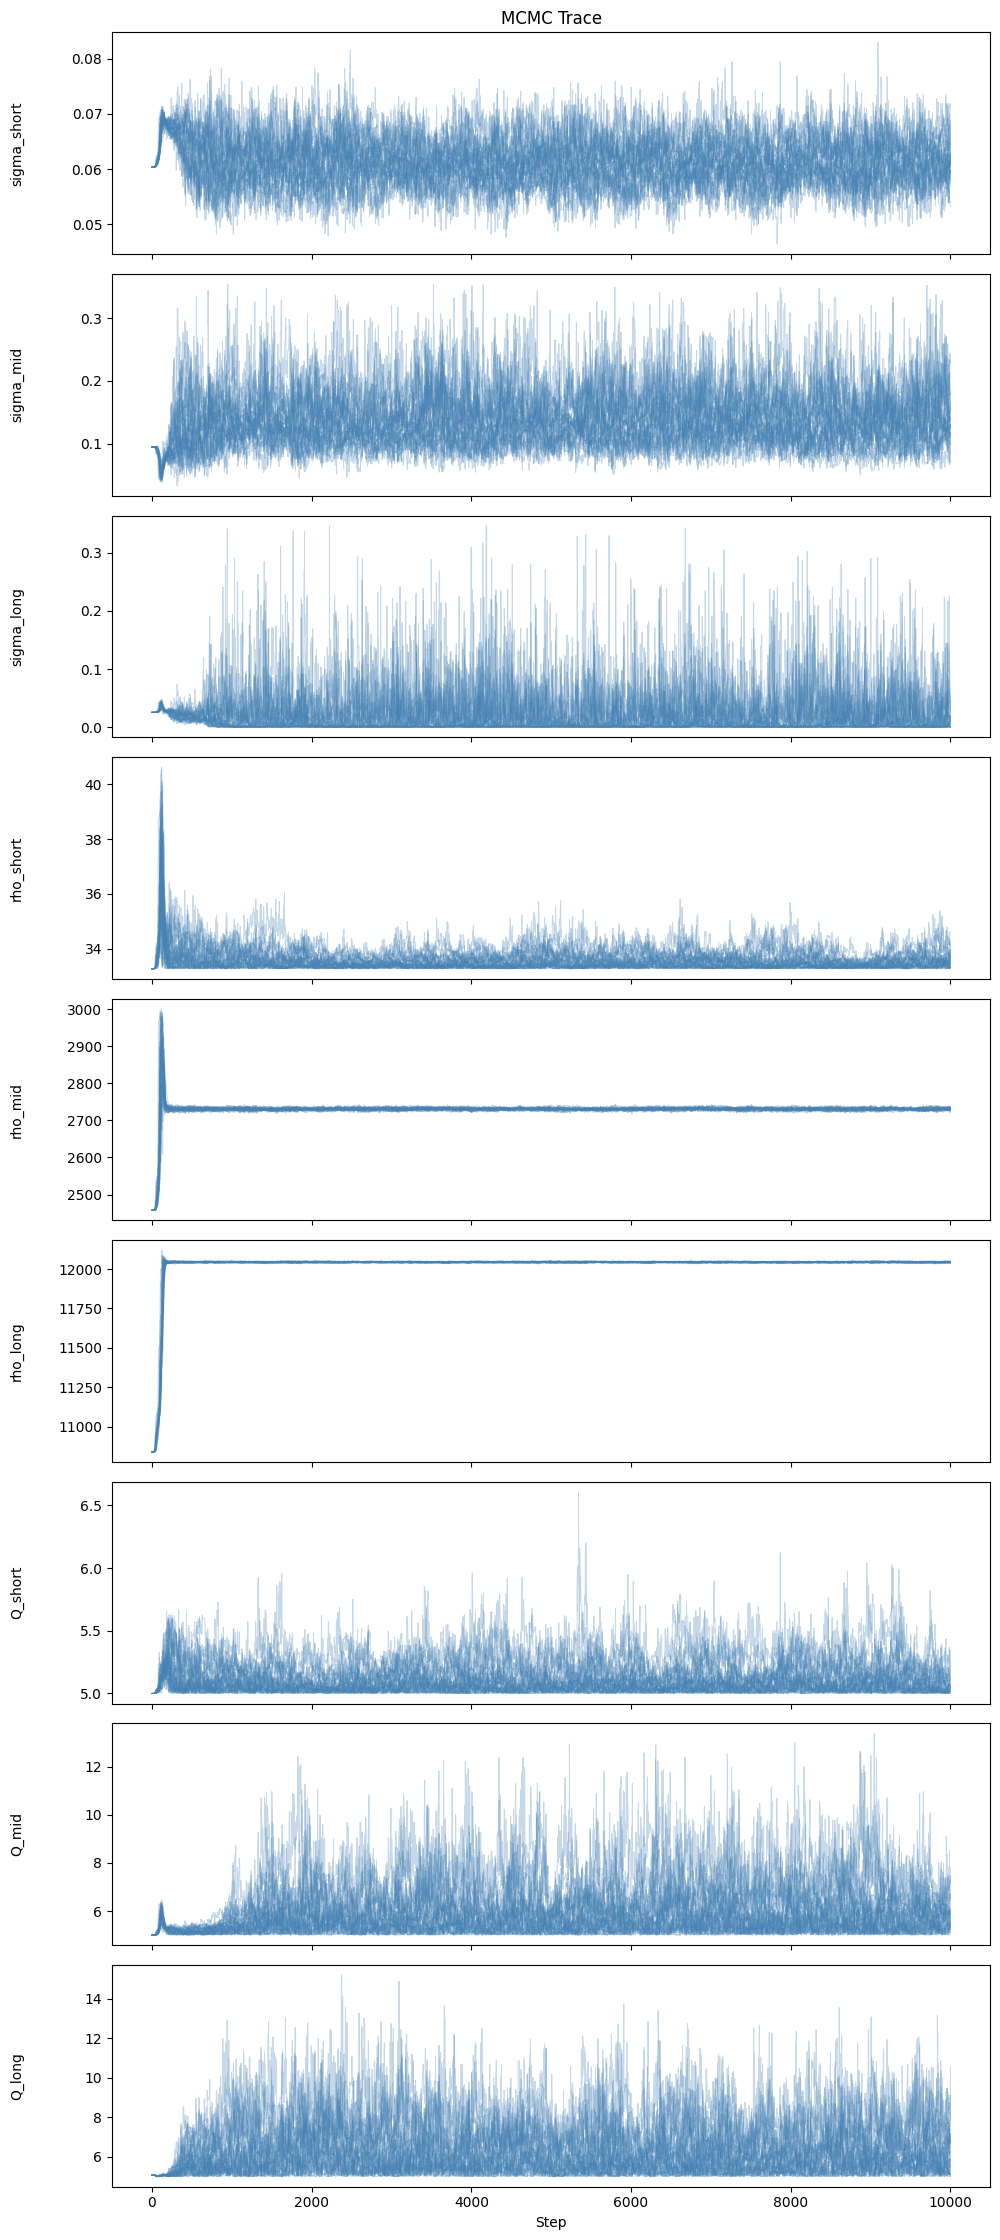

In [16]:
def plot_trace(sampler, param_names=None):
    samples = sampler.get_chain()  # shape: (n_steps, n_walkers, n_params)
    n_steps, n_walkers, n_params = samples.shape

    if param_names is None:
        param_names = [f"param_{i}" for i in range(n_params)]

    fig, axes = plt.subplots(n_params, 1, figsize=(10, 2.5 * n_params), sharex=True)
    if n_params == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        ax.plot(np.exp(samples[:, :, i]), color="steelblue", alpha=0.3, lw=0.7)
        ax.set_ylabel(param_names[i])
        ax.yaxis.set_label_coords(-0.1, 0.5)

    axes[-1].set_xlabel("Step")
    axes[0].set_title("MCMC Trace")
    fig.tight_layout()
    plt.show()

cycle_keys = prior_combos[best_combo]['cycle_keys']
param_names = (
    [f'sigma_{ck}' for ck in cycle_keys] +
    [f'rho_{ck}'   for ck in cycle_keys] +
    [f'Q_{ck}'     for ck in cycle_keys]
)

plot_trace(sampler, param_names)

- Looks like I should remove the first 1000 or so.

In [ ]:
samples = sampler.get_chain(discard=1000)

# Now plot the posterior


The best params were found for 3sml with NLPD of -1.229454093534564.
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.0604 | 5.00 |   33.27    |     0.09    |
| 0.0951 | 5.00 |  2457.62   |     6.73    |
| 0.0255 | 5.07 |  10839.03  |    29.70    |
+--------+------+------------+-------------+


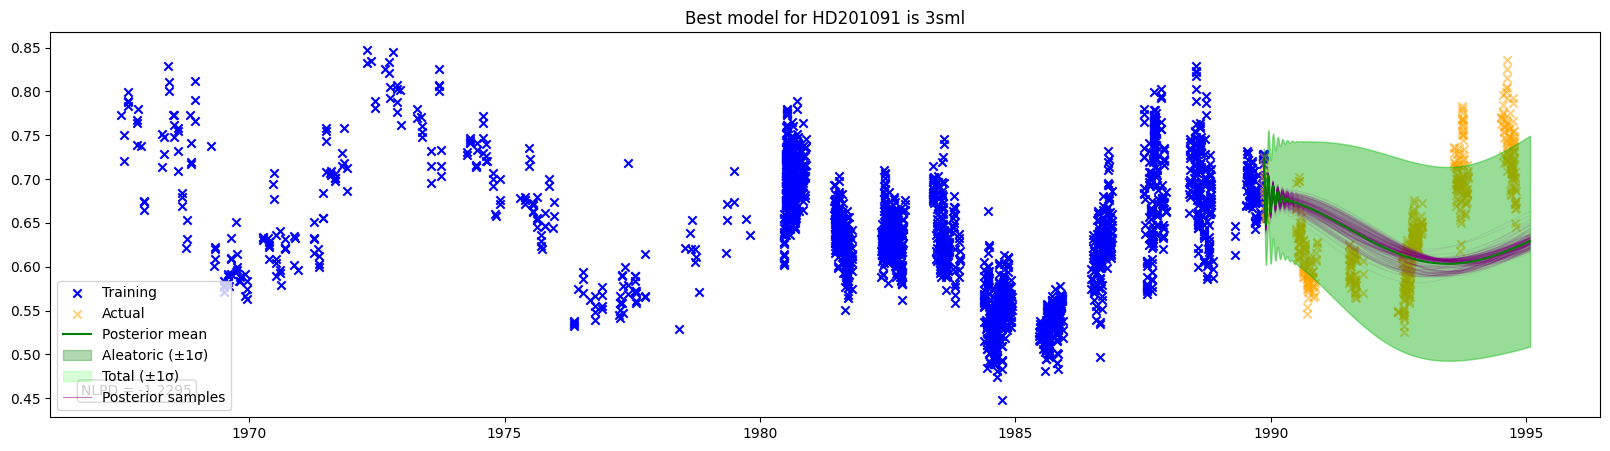

In [26]:

# Predict on a dense regular grid for smooth plotting
t_start = valid_df['day'].iloc[0]
t_end   = valid_df['day'].iloc[-1] + result_plot_extra
sampled_days = np.arange(t_start, t_end, result_plot_cadence)

mu, cov = best_gp.predict(train_df['sind'], t=sampled_days, return_var=True)
std = np.sqrt(cov)
results = pd.DataFrame({
        'forecast': mu,
        'lower':    mu - std,
        'upper':    mu + std,
}, index=sampled_days)

# Convert sampled days to years for plotting
day_ref       = train_df['day'].iloc[0]
year_ref      = train_df['year'].iloc[0]
sampled_years = year_ref + (sampled_days - day_ref) / 365.25

if results_verbose: # Print best model params
        print(f"The best params were found for {best_combo} with NLPD of {best_NLPD}.")
        k = prior_combos[best_combo]['k']
        table = PrettyTable(["sigma", "Q", "rho (days)", "rho (years)"])
        best_sigmas = best_params[0:k]
        best_rhos   = best_params[k:2*k]
        best_qs     = best_params[2*k:]
        for k_idx in range(k):
                table.add_row([f"{best_sigmas[k_idx]:.4f}", f"{best_qs[k_idx]:.2f}",
                                f"{best_rhos[k_idx]:.2f}", f"{best_rhos[k_idx]/365:.2f}"])
        print(table)

# if results_plot: # Plot best model predictions
#         if ax is None: # Enables passthrough
#                 fig, ax = plt.subplots(figsize=(20, 5))
#         ax.scatter(train_df['year'], train_df['sind'], color='blue', label='Training', marker='x')
#         ax.scatter(valid_df['year'], valid_df['sind'], color='orange', label='Actual', alpha=0.5, marker = 'x')
        

#         ax.set_title(f"Best model for {star_name} is {best_combo}")
#         ax.plot(sampled_years, results['forecast'], color='green', label='Predictions')
#         ax.fill_between(sampled_years, results['lower'], results['upper'],
#                         color='green', alpha=0.2, label='Uncertainties')
#         ax.legend()
#         ax.text(0.02, 0.05, f"NLPD = {best_NLPD:.4f}",
#                 transform=ax.transAxes, fontsize=10, verticalalignment='bottom',
#                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# if results_plot:
#         if ax is None:
#                 fig, ax = plt.subplots(figsize=(20, 5))

#         # Posterior samples
#         chain = sampler.get_chain(discard=100, flat=True)
#         k = prior_combos[best_combo]['k']
#         y_train = train_df['sind'].to_numpy()
#         for sample in chain[np.random.randint(len(chain), size=50)]:
#                 best_gp = set_params(sample, k, best_gp)
#                 best_gp.recompute(quiet=True)
#                 mu_sample = best_gp.predict(y_train, t=sampled_days)
#                 ax.plot(sampled_years, mu_sample, color='purple', alpha=0.15, lw=0.8)

#         # Reset best_gp back to MAP params before plotting the green line
#         best_gp = set_params(np.log(best_params), k, best_gp)
#         best_gp.recompute()

#         ax.scatter(train_df['year'], train_df['sind'], color='blue', label='Training', marker='x')
#         ax.scatter(valid_df['year'], valid_df['sind'], color='orange', label='Actual', alpha=0.5, marker='x')
#         ax.set_title(f"Best model for {star_name} is {best_combo}")
#         ax.plot(sampled_years, results['forecast'], color='green', label='MAP prediction')
#         ax.fill_between(sampled_years, results['lower'], results['upper'],
#                         color='green', alpha=0.2, label='MAP uncertainty')
#         ax.plot([], [], color='purple', alpha=0.5, lw=0.8, label='Posterior samples')
#         ax.legend()
#         ax.text(0.02, 0.05, f"NLPD = {best_NLPD:.4f}",
#                 transform=ax.transAxes, fontsize=10, verticalalignment='bottom',
#                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))


# ax = None

# if results_plot:
#         fig, ax = plt.subplots(figsize=(20, 5)) 

#         chain  = sampler.get_chain(discard=100, flat=True)
#         k      = prior_combos[best_combo]['k']
#         y_train = train_df['sind'].to_numpy()

#         mus, vars_ = [], []
#         for sample in chain[np.random.randint(len(chain), size=200)]:
#                 best_gp = set_params(sample, k, best_gp)
#                 best_gp.recompute(quiet=True)
#                 mu_s, var_s = best_gp.predict(y_train, t=sampled_days, return_var=True)
#                 mus.append(mu_s)
#                 vars_.append(var_s)
#                 ax.plot(sampled_years, mu_s, color='purple', alpha=0.1, lw=0.6)

#         mus, vars_ = np.array(mus), np.array(vars_)
#         mean_prediction = mus.mean(axis=0)
#         aleatoric_var   = vars_.mean(axis=0)
#         epistemic_var   = mus.var(axis=0)
#         total_std       = np.sqrt(aleatoric_var + epistemic_var)

#         # Reset best_gp to MAP
#         best_gp = set_params(np.log(best_params), k, best_gp)
#         best_gp.recompute()

#         ax.scatter(train_df['year'], train_df['sind'], color='blue', label='Training', marker='x')
#         ax.scatter(valid_df['year'], valid_df['sind'], color='orange', label='Actual', alpha=0.5, marker='x')
#         ax.set_title(f"Best model for {star_name} is {best_combo}")
#         ax.plot(sampled_years, mean_prediction, color='green', label='Posterior mean')
#         ax.fill_between(sampled_years,
#                         mean_prediction - np.sqrt(aleatoric_var),
#                         mean_prediction + np.sqrt(aleatoric_var),
#                         color='green', alpha=0.3, label='Aleatoric (±1σ)')
#         ax.fill_between(sampled_years,
#                         mean_prediction - total_std,
#                         mean_prediction + total_std,
#                         color='green', alpha=0.15, label='Total (±1σ)')
#         ax.plot([], [], color='purple', alpha=0.5, lw=0.8, label='Posterior samples')
#         ax.legend()
#         ax.text(0.02, 0.05, f"NLPD = {best_NLPD:.4f}",
#                 transform=ax.transAxes, fontsize=10, verticalalignment='bottom',
#                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
#         plt.show()

ax = None

if results_plot:
        fig, ax = plt.subplots(figsize=(20, 5))

        chain   = sampler.get_chain(discard=100, flat=True)
        k       = prior_combos[best_combo]['k']
        y_train = train_df['sind'].to_numpy()

        mus, vars_ = [], []
        for sample in chain[np.random.randint(len(chain), size=200)]:
                best_gp = set_params(sample, k, best_gp)
                best_gp.recompute(quiet=True)
                mu_s, var_s = best_gp.predict(y_train, t=sampled_days, return_var=True)
                mus.append(mu_s)
                vars_.append(var_s)

        mus, vars_ = np.array(mus), np.array(vars_)
        mean_prediction = mus.mean(axis=0)
        aleatoric_var   = vars_.mean(axis=0)
        epistemic_var   = mus.var(axis=0)
        total_std       = np.sqrt(aleatoric_var + epistemic_var)

        # Reset best_gp to MAP
        best_gp = set_params(np.log(best_params), k, best_gp)
        best_gp.recompute()

        ax.plot(sampled_years, mus.T, color='purple', alpha=0.1, lw=0.6)
        ax.scatter(train_df['year'], train_df['sind'], color='blue', label='Training', marker='x')
        ax.scatter(valid_df['year'], valid_df['sind'], color='orange', label='Actual', alpha=0.5, marker='x')
        ax.set_title(f"Best model for {star_name} is {best_combo}")
        ax.plot(sampled_years, mean_prediction, color='green', label='Posterior mean')
        ax.fill_between(sampled_years,
                        mean_prediction - np.sqrt(aleatoric_var),
                        mean_prediction + np.sqrt(aleatoric_var),
                        color='green', alpha=0.3, label='Aleatoric (±1σ)')
        ax.fill_between(sampled_years,
                        mean_prediction - total_std,
                        mean_prediction + total_std,
                        color='lime', alpha=0.15, label='Total (±1σ)')
        ax.plot([], [], color='purple', alpha=0.5, lw=0.8, label='Posterior samples')
        ax.legend()
        ax.text(0.02, 0.05, f"NLPD = {best_NLPD:.4f}",
                transform=ax.transAxes, fontsize=10, verticalalignment='bottom',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
        plt.show()

- Seems legit.
- I am a bit put off by the whole winner takes all model selection: some of the NLLs are very similar.
- RJMCMC hard to design.
- Can perform initial model selection many times with slightly stochastic starting points. Get the best.
- Then sample from the top few. Then use posterior samples based on the best likelihood. BMA: instead of picking one model and committing to it, you make predictions that are a weighted average across all models, where the weights reflect how probable each model is given the data.
